In [17]:
import numpy as np
from wfdb import rdrecord
import wfdb.processing as proc
from scipy.signal import buttord, butter, filtfilt
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({"font.size":16})

In [18]:
record = rdrecord("../data/dataset/02399", sampfrom=3062500, sampto=3063780)
nan_indices = np.where(np.isnan(record.p_signal[:, 0].astype(np.float32)))
nan_indices

(array([ 72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,
         85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
         98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
        111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123,
        124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136,
        137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149,
        150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162,
        163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175,
        176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188,
        189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201,
        202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214,
        215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227,
        228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240,
        241, 242, 243, 244, 245, 246, 247, 248, 249

[]

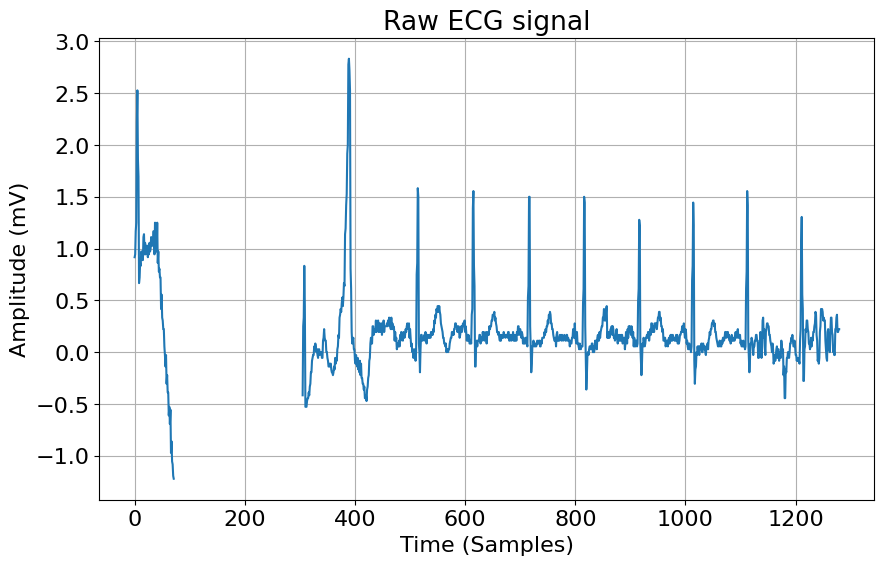

In [19]:
plt.figure(0, figsize=(10,6))
plt.plot(record.p_signal[:, 0])
plt.title("Raw ECG signal")
plt.xlabel('Time (Samples)')
plt.ylabel('Amplitude (mV)')
plt.grid(True)
plt.plot()

[]

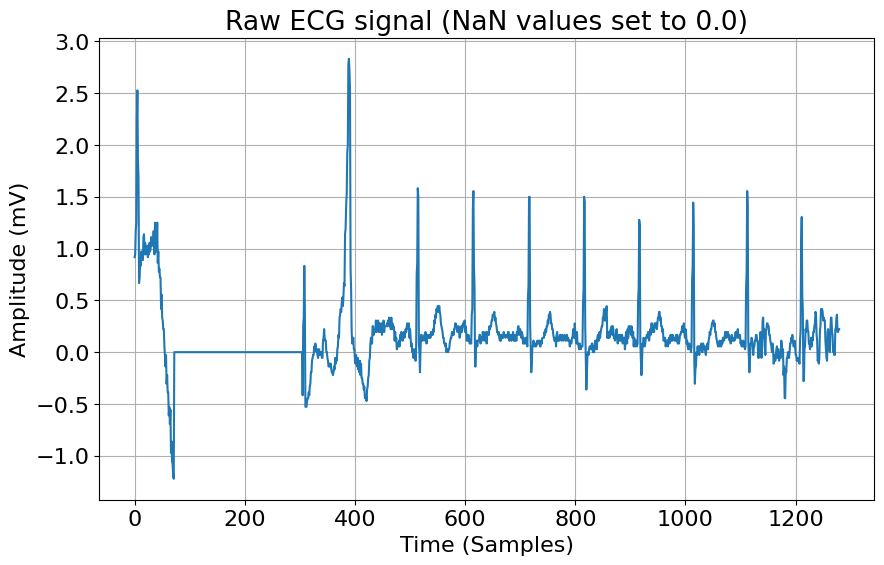

In [20]:
NaN_ECG_sig = np.nan_to_num(record.p_signal[:, 0], nan=0.0)
plt.figure(1, figsize=(10,6))
plt.plot(NaN_ECG_sig)
plt.title("Raw ECG signal (NaN values set to 0.0)")
plt.xlabel('Time (Samples)')
plt.ylabel('Amplitude (mV)')
plt.grid(True)
plt.plot()

Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.


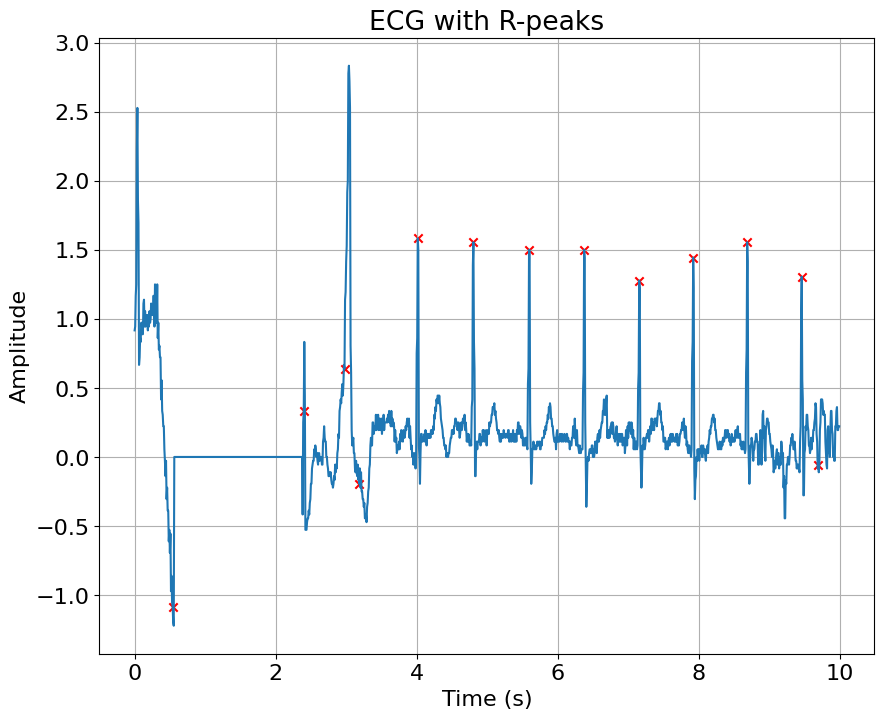

In [21]:
fs = 128
qrs_indices = proc.xqrs_detect(NaN_ECG_sig, 128)
qrs_inds = proc.correct_peaks(
    sig=NaN_ECG_sig,
    peak_inds=qrs_indices,
    search_radius=int(0.2 * fs),  # 100 ms search window
    smooth_window_size=int(0.2 * fs)
)
t = np.arange(len(NaN_ECG_sig)) / fs

plt.figure(4, figsize=(10,8))
plt.scatter(t[qrs_indices], NaN_ECG_sig[qrs_indices], marker='x', c='red')
plt.plot(t, NaN_ECG_sig)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('ECG with R-peaks')
plt.grid(True)
plt.show()

In [22]:
def get_valid_fixed_windows(sig, fs, win_sec=5.0, max_zero_frac=0.05):
    win_samples = int(win_sec*fs)
    valid_segments = []
    valid_spans = []
    for start in range(0, len(sig) - win_samples+1, win_samples):
        end = start + win_samples
        win = sig[start:end]
        zero_frac = np.mean(win==0.0)
        if zero_frac <= max_zero_frac:
            valid_segments.append(win)
            valid_spans.append((start,end))
    return np.array(valid_segments), valid_spans

In [23]:
segments5s, spans5s = get_valid_fixed_windows(NaN_ECG_sig, fs)
print(f"Number of valid 5s windows: {len(segments5s)}")
print(f"Number of valid 5s spans: {len(spans5s)}")

Number of valid 5s windows: 1
Number of valid 5s spans: 1


In [24]:
fs = 128

wp = np.array([0.5, 40.0]) / (fs / 2)
ws = np.array([0.25, 45.0]) / (fs / 2)
gpass = 1
gstop = 40
order, wn = buttord(wp, ws, gpass, gstop)
b, a = butter(4, wn, btype='band')

def bandpass_filter(b, a, signal):
	filtered_signal = filtfilt(b,a,signal, axis=0)
	return filtered_signal

In [25]:
NaN_filtered_signal = bandpass_filter(b,a,NaN_ECG_sig)
windowed_filtered_signal = bandpass_filter(b,a,segments5s[0])

[]

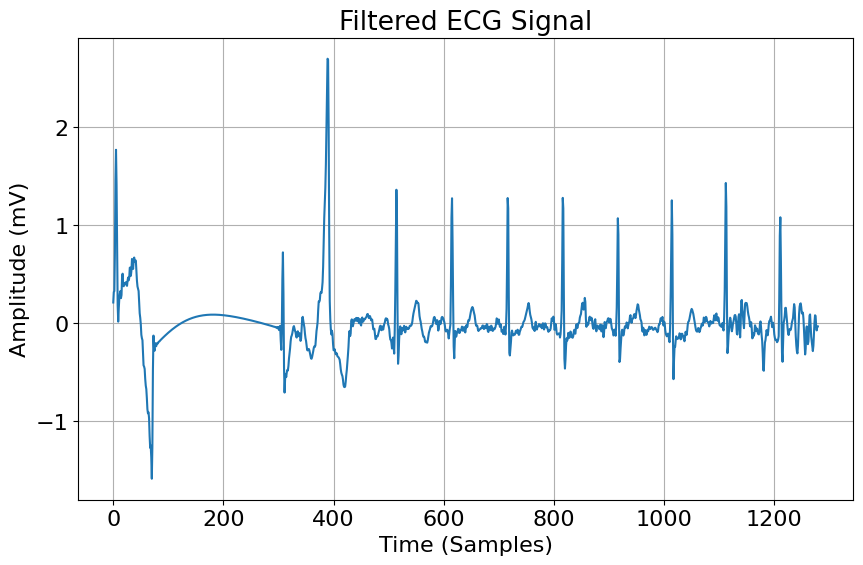

In [26]:
plt.figure(2, figsize=(10,6))
plt.plot(NaN_filtered_signal)
plt.title("Filtered ECG Signal")
plt.xlabel('Time (Samples)')
plt.ylabel('Amplitude (mV)')
plt.grid(True)
plt.plot()

In [39]:
qrs_indices = proc.xqrs_detect(windowed_filtered_signal, 128)
qrs_indices = proc.correct_peaks(
    sig=windowed_filtered_signal,
    peak_inds=qrs_indices,
    search_radius=int(0.3 * fs),  # 100 ms search window
    smooth_window_size=int(0.2 * fs)
)
t = np.arange(len(windowed_filtered_signal)) / fs

Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.


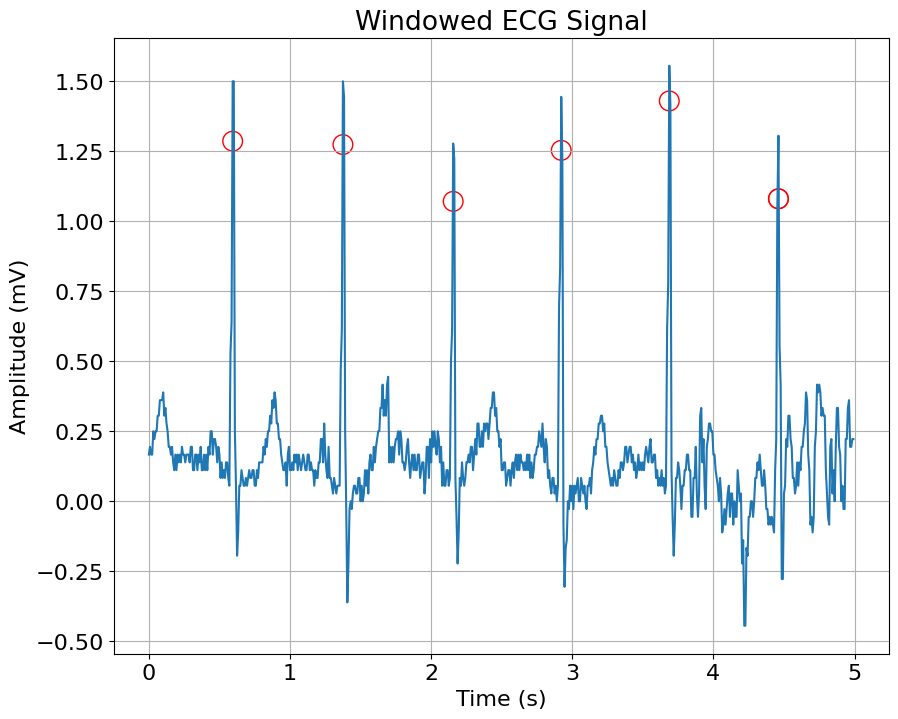

In [41]:
plt.figure(5, figsize=(10,8))
plt.plot(t,segments5s[0])
idx = np.asarray(qrs_indices).ravel().astype(int)
plt.scatter(t[idx], windowed_filtered_signal[idx], marker='o', facecolors='none', edgecolors='red', s=200)
plt.title("Windowed ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.show()

[]

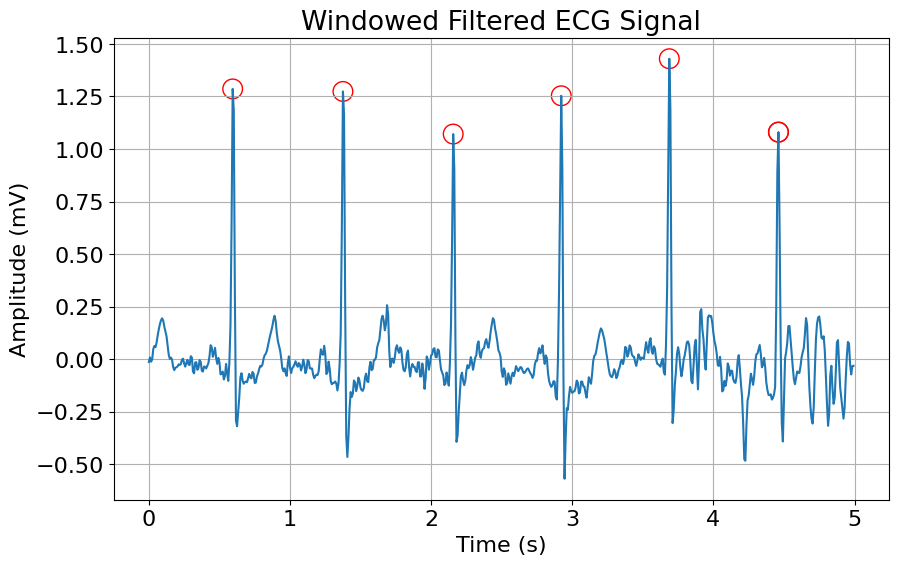

In [42]:
plt.figure(7, figsize=(10,6))
plt.plot(t, windowed_filtered_signal)
# ensure indices are integer 1D array and use the windowed signal for amplitudes
idx = np.asarray(qrs_indices).ravel().astype(int)
plt.scatter(t[idx], windowed_filtered_signal[idx], marker='o',s=200, facecolors='none', edgecolors='red')
plt.title("Windowed Filtered ECG Signal")
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.grid(True)
plt.plot()